# Reading polar-orbiter products: Metop and Sentinel-3

Polar-orbiting instruments see a strip of the Earth on each pass rather than a fixed disc,
so their data arrives as a swath: the latitude and longitude of every pixel are themselves
two-dimensional arrays. DEFAIR reads them through the same call it uses for geostationary
products, and hands back the same data model.

This tutorial reads five products from five instruments on four satellites and draws
each one. Nothing here
is product-specific except the reader name and the variable being drawn.

Prerequisite: the products this notebook reads, your own or downloaded through HDA, as [Install DEFAIR](../installation.md) explains. Point the paths in the code at your copies. For object storage, put the credentials in a `.env` file beside this notebook or in any parent folder, as `AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY` and `AWS_ENDPOINT_URL`.

In [1]:
import warnings
from pathlib import Path

import numpy as np

from defair_data.core import Dataset
from defair_data.dask_manager import close_dask_client
from defair.logging import setup_logging
from defair.plugin_manager import load_source

# Readers log every step at DEBUG. WARNING keeps this notebook's output to what the
# tutorial prints, and is the level to raise when a read does something unexpected.
setup_logging(log_level="WARNING")

import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print("cartopy not installed, maps will be drawn without coastlines")

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


In [2]:
def quicklook(dataset, variable, title, cmap="viridis"):
    """Draw one variable of a DEFAIR dataset on a map.

    Every product below is read through the same call and drawn through this same
    helper, which is the point of the tutorial: the reader differs, the shape of the
    work does not. Handles both the 1-D coordinates of a gridded product and the 2-D
    coordinates of a swath.
    """
    lat = dataset.data["lat"] if "lat" in dataset.data.coords else dataset.data["latitude"]
    lon = dataset.data["lon"] if "lon" in dataset.data.coords else dataset.data["longitude"]

    # Reduce to the two axes the coordinates span. Products put their spare axes in
    # different places, time first but channel or band last, so take the first index of
    # every axis lat and lon do not cover rather than assuming the leading one is spare.
    field = dataset.data[variable]
    spare = [dim for dim in field.dims if dim not in set(lat.dims) | set(lon.dims)]
    if spare:
        field = field.isel(dict.fromkeys(spare, 0), drop=True)

    # A quicklook needs a few million cells at most. Thin while the arrays are still lazy:
    # a full AVHRR orbit is 75 million pixels, and holding it with its coordinates in
    # float64 does not fit a 4 GB notebook server. Computing the field computes the
    # coordinates it carries in the same pass, so the granule is read once.
    step = max(1, int(np.sqrt(field.size / 4_000_000)))
    thin = lambda array: array.isel({dim: slice(None, None, step) for dim in array.dims})
    field = thin(field).compute()
    lat = field[lat.name] if lat.name in field.coords else thin(lat)
    lon = field[lon.name] if lon.name in field.coords else thin(lon)

    lat, lon = np.asarray(lat.squeeze().values), np.asarray(lon.squeeze().values)
    # ASCAT SZF publishes longitude on 0 to 360. Cartopy wraps those itself, but the
    # antimeridian test below compares raw longitudes, and on 0 to 360 the seam sits at
    # Greenwich instead; the plain-matplotlib fallback has no wrapping at all. The
    # conversion changes nothing for the readers that already publish -180 to 180.
    lon = np.where(lon > 180.0, lon - 360.0, lon)

    values = np.asarray(field.values, dtype=float)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        print(f"{title}: no finite values to draw")
        return
    vmin, vmax = np.percentile(finite, [2, 98])

    figure = plt.figure(figsize=(11, 7))
    axis = plt.axes(projection=ccrs.PlateCarree()) if HAS_CARTOPY else plt.axes()
    draw_kwargs = {"transform": ccrs.PlateCarree()} if HAS_CARTOPY else {}
    if lat.ndim == 1 and values.ndim == 2:
        lon, lat = np.meshgrid(lon, lat)

    # A mesh derives its cell boundaries from the midpoints between neighbouring pixels, so a
    # pair straddling the antimeridian becomes a cell spanning every longitude. A full orbit
    # crosses the antimeridian on every revolution, and this AVHRR granule has twenty thousand
    # such pairs, which is enough to tile the whole map. Those are drawn as points instead,
    # which carry no cell geometry; a scene that stays clear of the antimeridian gets the mesh,
    # because a subsample of points leaves unfilled gaps wherever the scene fills the figure.
    if max(np.nanmax(np.abs(np.diff(lon, axis=d))) for d in range(lon.ndim)) < 180.0:
        # A quicklook needs no more than a million cells. Striding the arrays keeps the
        # geometry, because the mesh reads the coordinates of every cell it draws.
        step = max(1, int(np.sqrt(values.size / 1_000_000)))
        mesh = axis.pcolormesh(
            lon[::step, ::step], lat[::step, ::step], values[::step, ::step],
            cmap=cmap, vmin=vmin, vmax=vmax, shading="nearest", **draw_kwargs,
        )
    else:
        # The subsample is random with a fixed seed rather than strided, because a stride lines
        # up with the cross-track scan and leaves scalloped gaps.
        finite = np.isfinite(values) & np.isfinite(lon) & np.isfinite(lat)
        plon, plat, pval = lon[finite], lat[finite], values[finite]
        if pval.size > 150_000:
            keep = np.random.default_rng(0).integers(0, pval.size, 150_000)
            plon, plat, pval = plon[keep], plat[keep], pval[keep]
        mesh = axis.scatter(plon, plat, c=pval, s=2, cmap=cmap, vmin=vmin, vmax=vmax, **draw_kwargs)
    if HAS_CARTOPY:
        axis.coastlines(linewidth=0.7)
        axis.add_feature(cfeature.BORDERS, linewidth=0.3)
        axis.gridlines(draw_labels=True, linewidth=0.2)
    axis.set_title(title, fontsize=13, fontweight="bold")
    units = dataset.data[variable].attrs.get("units", "")
    figure.colorbar(mesh, ax=axis, label=f"{variable} ({units})" if units else variable, shrink=0.75)
    plt.tight_layout()
    plt.show()


def inventory(dataset, label):
    """Print what a read produced, so each section shows the model DEFAIR built."""
    print(f"{label}")
    print(f"  dimensions: {dict(dataset.data.sizes)}")
    print(f"  variables:  {list(dataset.data.data_vars)[:8]}")
    print(f"  coordinates: {list(dataset.data.coords)[:8]}")


## Metop AVHRR Level-1B

AVHRR is the visible and infrared imager on the Metop satellites. Naming the reader is
optional, since DEFAIR recognises the product from the file itself, but naming it makes a
notebook say what it means.

In [6]:
# The listing shows what the bucket holds. The granule read below is pinned by name so
# the tutorial reads the same orbit every time.
AVHRR_PREFIX = "s3://datalake-demo-data/defair-notebook-data/metop-avhrr-l1b/"
avhrr_files = sorted(load_source("s3",endpoint_url="https://s3.central.data.destination-earth.eu",anon=True).list(AVHRR_PREFIX, pattern="*.nat"))
AVHRR_URI = AVHRR_PREFIX + "AVHR_xxx_1B_M01_20251231075503Z_20251231093703Z_N_O_20251231084335Z.nat"
assert AVHRR_URI in avhrr_files, f"granule not found under {AVHRR_PREFIX}: {AVHRR_URI}"
print(f"granule: {AVHRR_URI}")

avhrr = Dataset.from_source(
    AVHRR_URI,
    reader="metop_avhrrl1",
    source="s3",
    bands=["channel_4", "latitude", "longitude"],source_kwargs={"anon": True, "endpoint_url": "https://s3.central.data.destination-earth.eu"}
)
inventory(avhrr, "Metop AVHRR Level-1B")

granule: s3://datalake-demo-data/defair-notebook-data/metop-avhrr-l1b/AVHR_xxx_1B_M01_20251231075503Z_20251231093703Z_N_O_20251231084335Z.nat
Metop AVHRR Level-1B
  dimensions: {'time': 1, 'y': 36720, 'x': 2048, 'bnds': 2}
  variables:  ['channel_4']
  coordinates: ['time', 'latitude', 'longitude', 'crs', 'time_mdr', 'time_bnds']


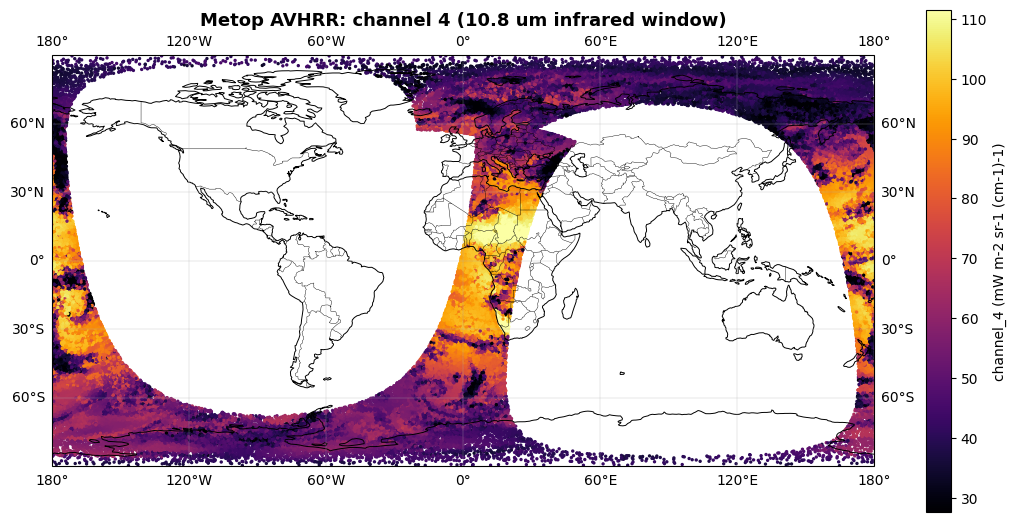

In [7]:
quicklook(avhrr, "channel_4", "Metop AVHRR: channel 4 (10.8 um infrared window)", cmap="inferno")

## Metop HIRS Fundamental Data Record

The Fundamental Data Record is the reprocessed, inter-calibrated form of the HIRS sounder
series. It carries brightness temperatures on a channel axis, so the quicklook helper takes
the first channel. Channel 1 is
the 14.95 micron carbon dioxide band, which sees the cold upper stratosphere rather than the
surface, so 205 to 260 K is the range to expect.

The HIRS granule starts and ends near the equator, so its first and last scanlines meet there
with 101 minutes of the Earth's rotation between them. That is the apparent break in the
Atlantic at 20 to 45 degrees west: the two ends of one orbit, 25 degrees of longitude apart,
rather than missing data.

The AVHRR granule above covers an orbit too, but its ends fall elsewhere, and the empty
Atlantic west of Europe is not a gap between passes. Consecutive Metop descending crossings
are 25 degrees of longitude apart and the AVHRR swath is about as wide, so neighbouring passes
meet. What is empty there is the rest of the globe, which one orbit of scanlines does not
reach. The arcs that loop above 70 north are the polar crossing drawn on a plate carree axis.

In [8]:
hirs = Dataset.from_source(
    "s3://datalake-demo-data/defair-notebook-data/metop-hirs-fdr/"
    "FDR_L1C_HIRS4_METOPB_20221231105621_20221231123735_R02.0.nc",
    reader="metop_hirs_fdr",
    source="s3",
    variables=["btemps", "satellite_zenith_angle"],source_kwargs={"anon": True, "endpoint_url": "https://s3.central.data.destination-earth.eu"}
)
inventory(hirs, "Metop HIRS Fundamental Data Record")

Metop HIRS Fundamental Data Record
  dimensions: {'time': 1, 'y': 950, 'x': 56, 'channel': 20, 'bnds': 2}
  variables:  ['btemps', 'satellite_zenith_angle']
  coordinates: ['time', 'channel', 'x', 'latitude', 'longitude', 'observation_time', 'wavenumber', 'crs']


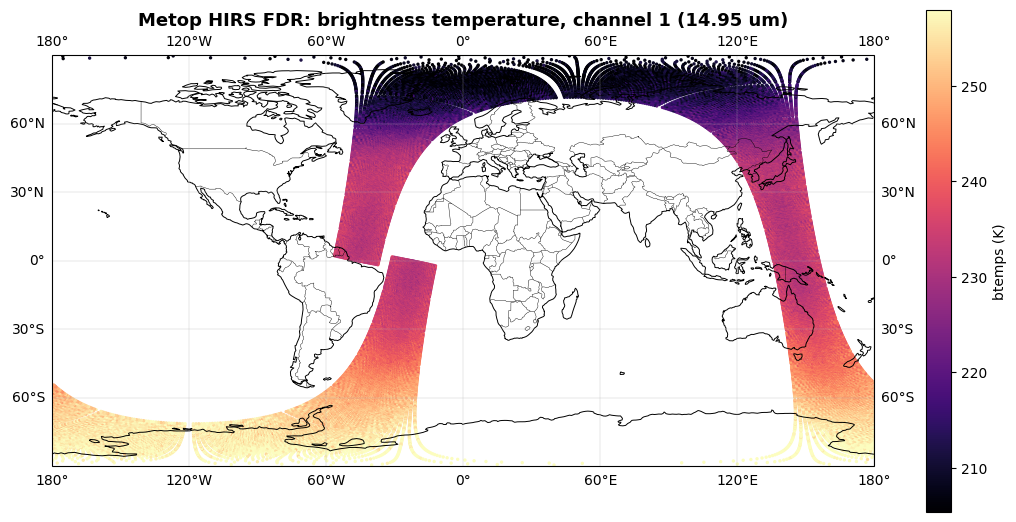

In [9]:
quicklook(hirs, "btemps", "Metop HIRS FDR: brightness temperature, channel 1 (14.95 um)", cmap="magma")

## Metop ASCAT sigma nought

ASCAT is a radar scatterometer: it measures the backscatter coefficient, sigma nought, from
which ocean surface wind is derived. This is the reprocessed full-resolution product.

In [10]:
ascat = Dataset.from_source(
    "s3://datalake-demo-data/defair-notebook-data/metop-ascat-szf/"
    "ASCA_SZF_1B_M02_20120622220000Z_20120622234159Z_R_O_20130828134436Z_0200.nat",
    reader="metop_ascszfr02",
    source="s3",
    bands=["sigma0_full", "latitude", "longitude"],source_kwargs={"anon": True, "endpoint_url": "https://s3.central.data.destination-earth.eu"}
)
inventory(ascat, "Metop ASCAT SZF reprocessed")

Metop ASCAT SZF reprocessed
  dimensions: {'time': 1, 'y': 43238, 'x': 192, 'bnds': 2}
  variables:  ['sigma0_full']
  coordinates: ['time', 'latitude', 'longitude', 'crs', 'time_mdr', 'time_bnds', 'beam_number']


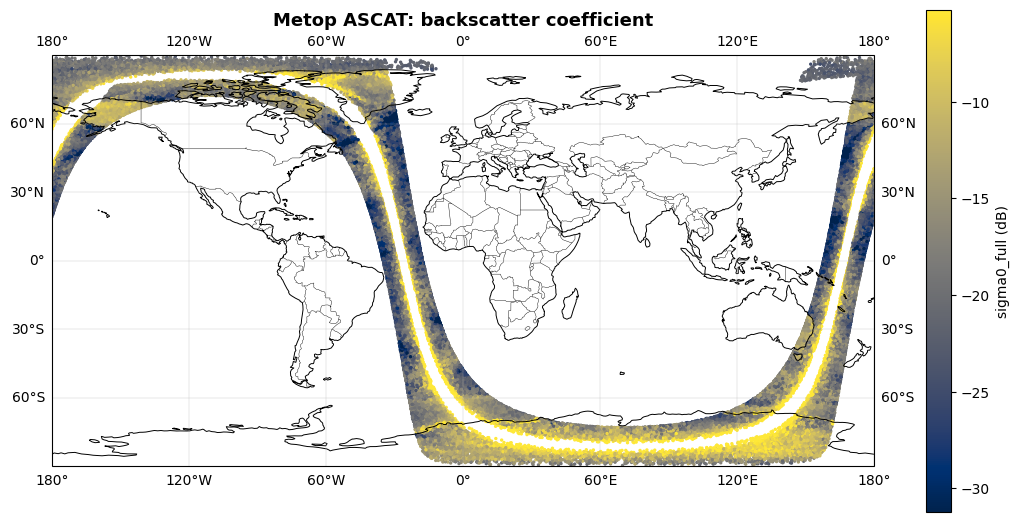

In [11]:
quicklook(ascat, "sigma0_full", "Metop ASCAT: backscatter coefficient", cmap="cividis")

## Sentinel-3 OLCI Level-1B

OLCI is the ocean and land colour imager on Sentinel-3. Its Level-1B product holds a
21-band radiance cube alongside geometry, meteorology and quality variables. The filter
keeps the cube and drops the rest; the plot below draws its first band.

In [12]:
with warnings.catch_warnings():
    # Two notices from this product, neither of which touches the radiances. The reader opens
    # each of the 21 band files with the chunking it wants rather than the chunking the file
    # was stored with, and xarray says so once per file; and one instrument-metadata variable
    # declares the same dimension name twice, which xarray also reports. Both are silenced
    # here rather than repeated over the cell's output.
    warnings.filterwarnings("ignore", message="The specified chunks separate the stored chunks")
    warnings.filterwarnings("ignore", message="Duplicate dimension names present")
    olci = Dataset.from_source(
        "s3://datalake-demo-data/defair-notebook-data/sentinel3-olci-efr/"
        "S3B_OL_1_EFR____20260425T094557_20260425T094857_20260426T121647_0179_119_193_2160_MAR_O_NT_004.SEN3",
        reader="sentinel3_ol_1_efr",source_kwargs={"anon": True, "endpoint_url": "https://s3.central.data.destination-earth.eu"}
    )
olci_band = olci.transform("content_filter", include_vars=["radiance"])
inventory(olci_band, "Sentinel-3 OLCI Level-1B, radiance cube only")

Sentinel-3 OLCI Level-1B, radiance cube only
  dimensions: {'time': 1, 'band': 21, 'rows': 4091, 'columns': 4865, 'tie_rows': 4091, 'tie_columns': 77, 'bnds': 2}
  variables:  ['radiance']
  coordinates: ['time', 'band', 'band_name', 'bandwidth', 'latitude', 'longitude', 'observation_time', 'crs']


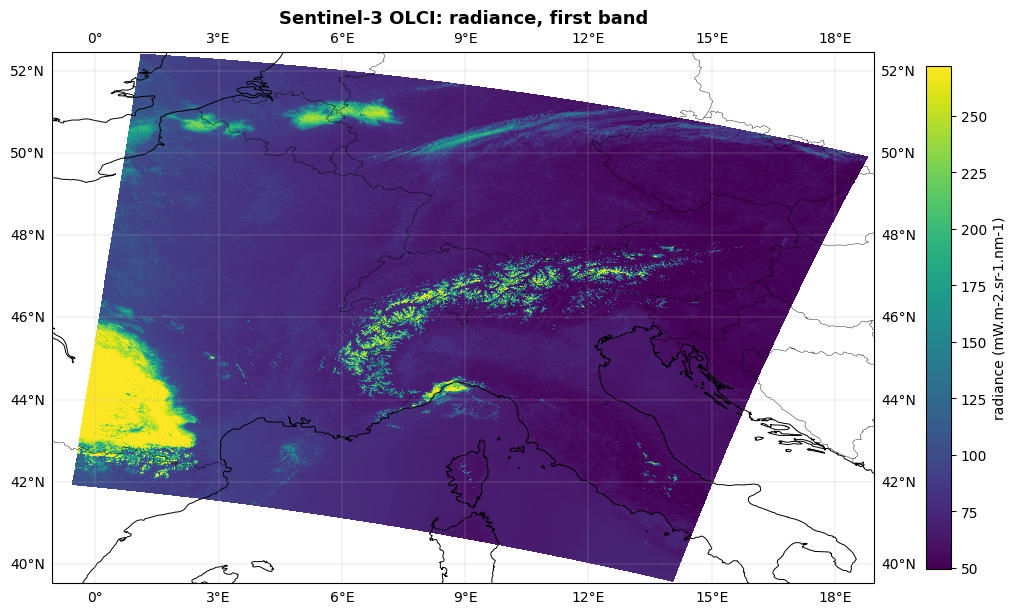

In [13]:
quicklook(olci_band, "radiance", "Sentinel-3 OLCI: radiance, first band", cmap="viridis")

## Sentinel-3 SLSTR fire radiative power

The SLSTR Level-2 fire product is two things at once: a one-dimensional list of detected
fires and a two-dimensional flag grid. Reading it shows that a DEFAIR dataset is not
obliged to be a single rectangular cube.

The read prints three notices about the product's metadata rather than its data: DEFAIR has
no CF template for this reader, and the granule's `classification` flag variable declares
twelve flag meanings against two masks and repeats the name `spare`. The fire list below is
unaffected, and the flag grid is left undrawn: decoding it needs the flag meanings the
granule declares incorrectly.

In [16]:
frp = Dataset.from_source(
    "s3://datalake-demo-data/defair-notebook-data/sentinel3-slstr-frp/"
    "S3A_SL_2_FRP____20250808T092333_20250808T092833_20250808T112937_0299_129_093______MAR_O_NR_003.SEN3",
    reader="sentinel3_frp",source_kwargs={"anon": True, "endpoint_url": "https://s3.central.data.destination-earth.eu"}
)
inventory(frp, "Sentinel-3 SLSTR fire radiative power")

fires = frp.data["FRP_MWIR"]
print(f"\nfire detections in this granule: {int(np.isfinite(fires.values).sum())}")

2026-09-29 02:14:26 | WARNING  | [0e02f9d8] defair.cf_history_mixin:apply_cf_global_metadata:368 - No CF metadata template for reader 'sentinel3_frp'
2026-09-29 02:14:26 | WARNING  | [0e02f9d8] defair_data.cf_flags:_flag_specs:162 - flag_meanings (12) and flag_masks/flag_values ([8, 8]) length differ on 'classification', decoding first 8 pairs
2026-09-29 02:14:26 | WARNING  | [0e02f9d8] defair_data.cf_flags:_flag_specs:186 - Flag name 'spare' repeats on 'classification'; the later declaration wins
2026-09-29 02:14:26 | WARNING  | [0e02f9d8] defair_data.dask_manager:release_client:717 - Release called but ref_count is already 0


Sentinel-3 SLSTR fire radiative power
  dimensions: {'time': 1, 'fires': 26, 'rows': 2000, 'columns': 1500, 'bnds': 2}
  variables:  ['FRP_MWIR', 'FRP_MWIR_uncertainty', 'Glint_angle', 'IFOV_area', 'MWIR_Fire_pixel_BT', 'MWIR_Fire_pixel_radiance', 'Radiance_window', 'S8_Fire_pixel_BT']
  coordinates: ['time', 'fire_latitude', 'fire_longitude', 'latitude', 'longitude', 'observation_time', 'time_bnds', 'crs']

fire detections in this granule: 26


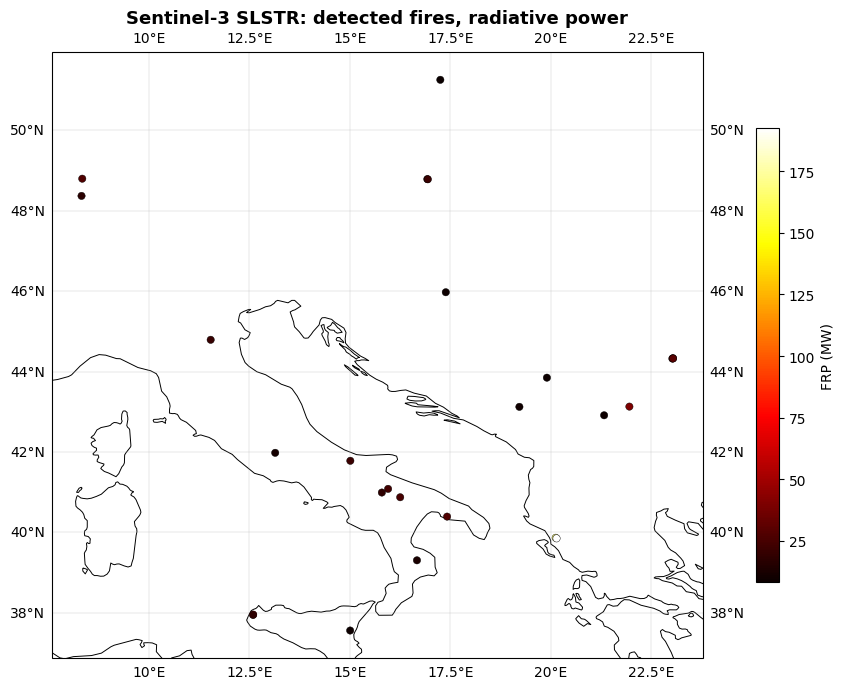

In [17]:
figure = plt.figure(figsize=(11, 7))
axis = plt.axes(projection=ccrs.PlateCarree()) if HAS_CARTOPY else plt.axes()
scatter_kwargs = {"transform": ccrs.PlateCarree()} if HAS_CARTOPY else {}
# FRP_MWIR is one value per detected fire, so it pairs with the per-fire coordinates.
# "latitude" and "longitude" are the 2000 by 1500 grid the flag raster sits on.
power = np.asarray(frp.data["FRP_MWIR"].values, dtype=float).ravel()
lat = np.asarray(frp.data["fire_latitude"].values, dtype=float).ravel()
lon = np.asarray(frp.data["fire_longitude"].values, dtype=float).ravel()
valid = np.isfinite(power) & np.isfinite(lat) & np.isfinite(lon)
# The two strongest fires in this granule sit 0.03 degrees apart on the Albanian coast, and
# "hot" maps its top value to white, so without an outline the detections that set the
# colourbar's upper end are a white marker on a white background. zorder keeps them above
# the coastline, which is drawn after them.
points = axis.scatter(
    lon[valid], lat[valid], c=power[valid], s=28, cmap="hot", zorder=3,
    edgecolors="black", linewidths=0.3, **scatter_kwargs,
)
if HAS_CARTOPY:
    axis.coastlines(linewidth=0.7)
    axis.gridlines(draw_labels=True, linewidth=0.2)
axis.set_title("Sentinel-3 SLSTR: detected fires, radiative power", fontsize=13, fontweight="bold")
figure.colorbar(points, ax=axis, label="FRP (MW)", shrink=0.75)
plt.tight_layout()
plt.show()

In [18]:
close_dask_client()
